## Imports

In [1]:
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_tabular
import lightning as L
import torch
import torch.nn as nn
import torchmetrics
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from pnpl.datasets import LibriBrainSpeech
from torch.utils.data import DataLoader
import lime_explanation
import lime_visualization
from models import SpeechClassifier, SpeechModel

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Load model

In [2]:
# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

checkpoint_path = "speech_model.ckpt"

# Load the SpeechClassifier model from checkpoint
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]
model = SpeechClassifier.load_from_checkpoint(checkpoint_path)

Seed set to 42
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.0, which is newer than your current Lightning version: v2.5.0.post0


## Load data

In [3]:
# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
num_workers = 0

In [4]:
train_run_keys = [("0",str(i),"Sherlock1","1") for i in range(1,10)]
train_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys = train_run_keys,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=num_workers)

(…)-0_ses-9_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock1/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/400M [00:00<?, ?B/s]

(…)-0_ses-3_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

(…)-0_ses-5_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

(…)-0_ses-4_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

...

Sherlock1/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/429M [00:00<?, ?B/s]

(…)-0_ses-8_task-Sherlock1_run-1_events.tsv: 0.00B [00:00, ?B/s]

Sherlock1/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/399M [00:00<?, ?B/s]

Sherlock1/derivatives/serialised/sub-0_s(…):   0%|          | 0.00/300M [00:00<?, ?B/s]

Done!
calculated stats for:  ('0', '1', 'Sherlock1', '1')
calculated stats for:  ('0', '2', 'Sherlock1', '1')
calculated stats for:  ('0', '3', 'Sherlock1', '1')
calculated stats for:  ('0', '4', 'Sherlock1', '1')
calculated stats for:  ('0', '5', 'Sherlock1', '1')
calculated stats for:  ('0', '6', 'Sherlock1', '1')
calculated stats for:  ('0', '7', 'Sherlock1', '1')
calculated stats for:  ('0', '8', 'Sherlock1', '1')
calculated stats for:  ('0', '9', 'Sherlock1', '1')


## Filter data

In [5]:
# These are the sensors we identified as being particularly useful
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]

class FilteredDataset(torch.utils.data.Dataset):
    """
    Parameters:
        dataset: LibriBrain dataset.
        limit_samples (int, optional): If provided, limits the length of the dataset to this
                          number of samples.
        speech_silence_only (bool, optional): If True, only includes segments that are either
                          purely speech or purely silence (with additional balancing).
        apply_sensors_speech_mask (bool, optional): If True, applies a fixed sensor mask to the sensor
                          data in each sample.
    """
    def __init__(self,
                 dataset,
                 limit_samples=None,
                 disable=False,
                 apply_sensors_speech_mask=True):
        self.dataset = dataset
        self.limit_samples = limit_samples
        self.apply_sensors_speech_mask = apply_sensors_speech_mask

        # These are the sensors we identified:
        self.sensors_speech_mask = SENSORS_SPEECH_MASK

        self.balanced_indices = list(range(len(dataset.samples)))
        # Shuffle the indices
        self.balanced_indices = random.sample(self.balanced_indices, len(self.balanced_indices))

    def __len__(self):
        """Returns the number of samples in the filtered dataset."""
        if self.limit_samples is not None:
            return self.limit_samples
        return len(self.balanced_indices)

    def __getitem__(self, index):
        # Map index to the original dataset using balanced indices
        original_idx = self.balanced_indices[index]
        if self.apply_sensors_speech_mask:
            sensors = self.dataset[original_idx][0][self.sensors_speech_mask]
        else:
            sensors = self.dataset[original_idx][0][:]
        label_from_the_middle_idx = self.dataset[original_idx][1].shape[0] // 2
        return [sensors, self.dataset[original_idx][1][label_from_the_middle_idx]]

train_data_filtered = FilteredDataset(train_data)
train_loader_filtered = DataLoader(train_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

## Run LIME for multiple instances of speech and silence

In [6]:
model.eval()
speech_cntr = 0
silence_cntr = 0

# lime hyperparams
perturb_function = lime_explanation.perturb_mean
num_slices = 40
num_perturbations = 150
kernel_width = 0.25
number_of_top_features = 5
important_segment_indices_speech = []
n_instances = 100
total_signal_speech = np.zeros((n_instances, 23, 200))
important_segment_indices_silence = []
total_signal_silence = np.zeros((n_instances, 23, 200))

for batch_idx, (curr_batch_inputs, curr_batch_labels) in enumerate(iter(train_loader_filtered)):
    if speech_cntr >= n_instances and silence_cntr >= n_instances:
        break

    print(f"Running LIME for batch {batch_idx+1}... # Speech: {speech_cntr} | # Silence: {silence_cntr}")
    for curr_input, curr_label in zip(curr_batch_inputs, curr_batch_labels):
        if (curr_label == 1 and speech_cntr >= n_instances and silence_cntr < n_instances) or (curr_label == 0 and speech_cntr < 0 and silence_cntr >= n_instances):
            continue

        seq = curr_input.detach().numpy()
        
        # segment signal
        slice_width = lime_explanation.segment_ecg_signal(seq, num_slices)

        # generate perturbations
        random_perturbations = lime_explanation.generate_random_perturbations(num_perturbations, num_slices)

        # apply perturbations -- calc class probabilities
        perturbation_predictions = lime_explanation.predict_perturbations(model, seq, random_perturbations, num_slices, perturb_function)

        # calc cosine distances and compute weights
        cosine_distances = lime_explanation.calculate_cosine_distances(random_perturbations, num_slices)
        weights = lime_explanation.calculate_weights_from_distances(cosine_distances, kernel_width)

        # train interpretable model
        segment_importance_coefficients = lime_explanation.fit_explainable_model(perturbation_predictions, random_perturbations, weights, target_class=curr_label)

        # identify most important features
        top_influential_segments = lime_explanation.identify_top_influential_segments(segment_importance_coefficients, number_of_top_features)

        if curr_label == 1:
            total_signal_speech[speech_cntr, :, :] = seq
            important_segment_indices_speech.extend(top_influential_segments)
            speech_cntr += 1
        else:
            total_signal_silence[silence_cntr, :, :] = seq
            important_segment_indices_silence.extend(top_influential_segments)
            silence_cntr += 1
        
        if speech_cntr >= n_instances and silence_cntr >= n_instances:
            break

important_segment_indices_speech = np.array(important_segment_indices_speech).flatten()
important_segment_indices_silence = np.array(important_segment_indices_silence).flatten()

Running LIME for batch 1... # Speech: 0 | # Silence: 0


[W1203 10:23:49.770602000 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


Running LIME for batch 2... # Speech: 24 | # Silence: 8
Running LIME for batch 3... # Speech: 48 | # Silence: 16
Running LIME for batch 4... # Speech: 76 | # Silence: 20
Running LIME for batch 5... # Speech: 100 | # Silence: 25
Running LIME for batch 6... # Speech: 100 | # Silence: 32
Running LIME for batch 7... # Speech: 100 | # Silence: 41
Running LIME for batch 8... # Speech: 100 | # Silence: 49
Running LIME for batch 9... # Speech: 100 | # Silence: 61
Running LIME for batch 10... # Speech: 100 | # Silence: 64
Running LIME for batch 11... # Speech: 100 | # Silence: 72
Running LIME for batch 12... # Speech: 100 | # Silence: 77
Running LIME for batch 13... # Speech: 100 | # Silence: 83
Running LIME for batch 14... # Speech: 100 | # Silence: 94


## Visualize most important segments

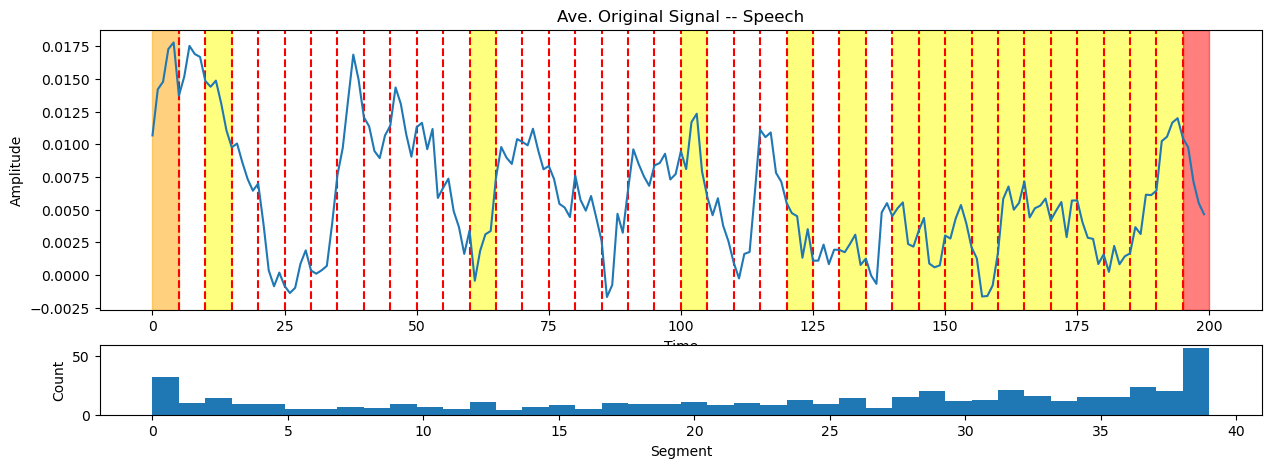

In [9]:
ave_total_signal = total_signal_speech.mean(axis=0).mean(axis=0)
n_samples = ave_total_signal.shape[-1]

counts, bins = np.histogram(important_segment_indices_speech,bins=num_slices)
def get_color(count, total_n):
    if count <= int(total_n*0.1):
        return "grey" # 10%
    elif count <= int(total_n*0.25):
        return "yellow" # 25%
    elif count <= int(total_n*0.5):
        return "orange" # 50%
    else:
        return "red" # >50%
seg_colors = [get_color(count, n_instances) for count in counts]

fig,axes = plt.subplots(2,1,figsize=(15, 5),height_ratios=(4,1))

for i in range(1, num_slices):
    axes[0].axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')

axes[0].plot(ave_total_signal, label='Original ECG Signal')
for seg_idx,seg_color in zip(range(num_slices),seg_colors):
    if seg_color == "grey":
        continue
    start_idx = seg_idx * (n_samples // num_slices)
    end_idx = start_idx + (n_samples // num_slices)
    axes[0].axvspan(start_idx, end_idx, color=seg_color, alpha=0.5)  # Highlight influential segments

axes[0].set_title('Ave. Original Signal -- Speech')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')

axes[1].hist(important_segment_indices_speech,bins=num_slices)
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Count")

plt.show()

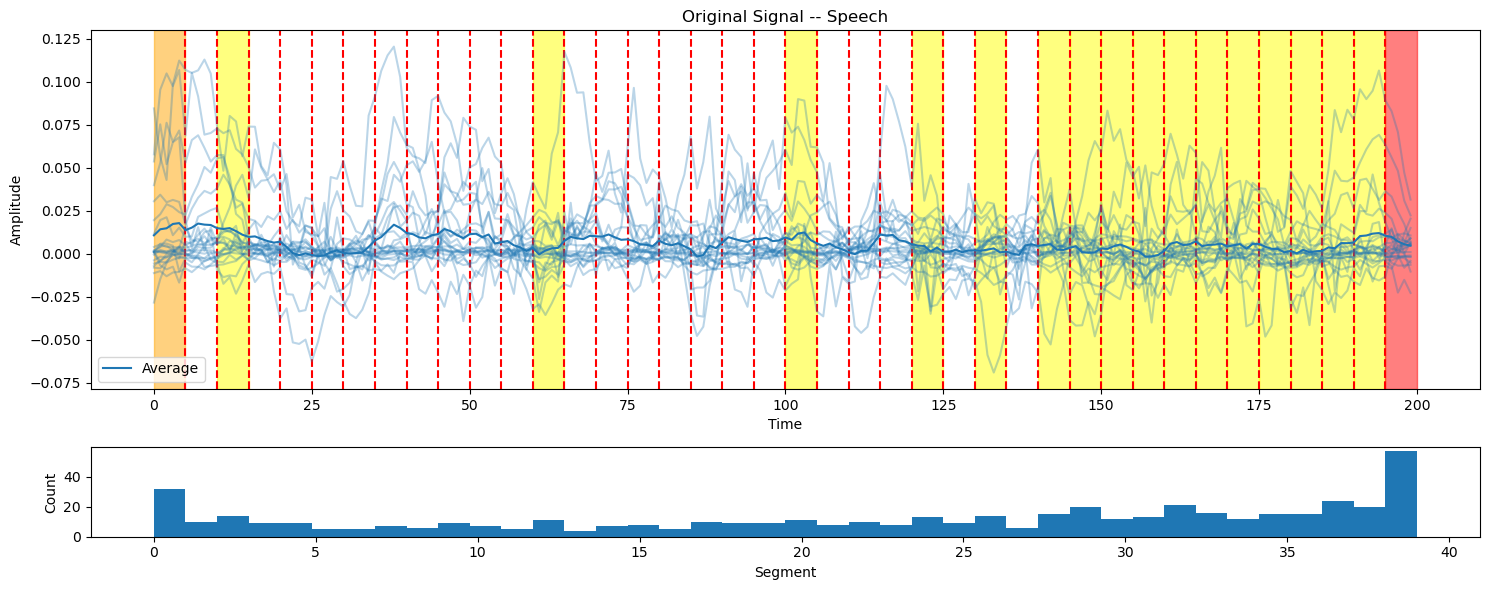

In [15]:
ave_channel_signal = total_signal_speech.mean(axis=0).reshape((23,200))
ave_total_signal = total_signal_speech.mean(axis=0).mean(axis=0)
n_samples = ave_total_signal.shape[-1]

counts, bins = np.histogram(important_segment_indices_speech,bins=num_slices)
def get_color(count, total_n):
    if count <= int(total_n*0.1):
        return "grey" # 10%
    elif count <= int(total_n*0.25):
        return "yellow" # 25%
    elif count <= int(total_n*0.5):
        return "orange" # 50%
    else:
        return "red" # >50%
seg_colors = [get_color(count, n_instances) for count in counts]

fig,axes = plt.subplots(2,1,figsize=(15, 6),height_ratios=(4,1))

for i in range(1, num_slices):
    axes[0].axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')

for i in range(23):
    axes[0].plot(ave_channel_signal[i], alpha=0.3, color="tab:blue")
axes[0].plot(ave_total_signal, color="tab:blue", label="Average")
axes[0].legend()
for seg_idx,seg_color in zip(range(num_slices),seg_colors):
    if seg_color == "grey":
        continue
    start_idx = seg_idx * (n_samples // num_slices)
    end_idx = start_idx + (n_samples // num_slices)
    axes[0].axvspan(start_idx, end_idx, color=seg_color, alpha=0.5)  # Highlight influential segments

axes[0].set_title('Original Signal -- Speech')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')

axes[1].hist(important_segment_indices_speech,bins=num_slices)
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

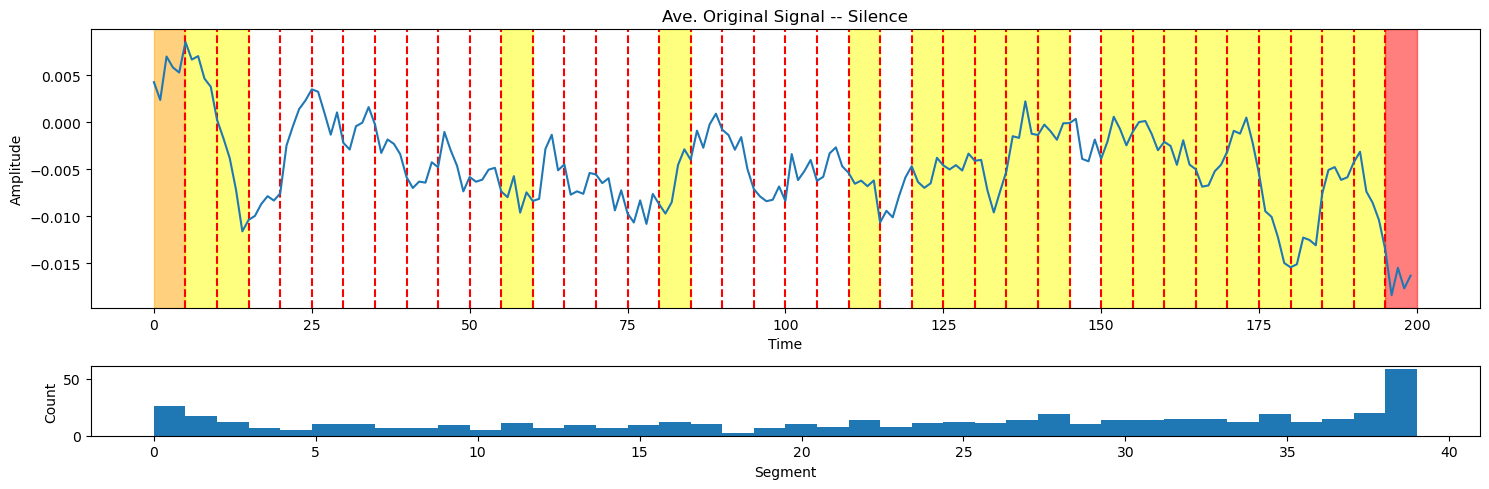

In [29]:
ave_total_signal = total_signal_silence.mean(axis=0).mean(axis=0)
n_samples = ave_total_signal.shape[-1]

counts, bins = np.histogram(important_segment_indices_silence,bins=num_slices)
def get_color(count, total_n):
    if count <= int(total_n*0.1):
        return "grey"
    elif count <= int(total_n*0.25):
        return "yellow"
    elif count <= int(total_n*0.5):
        return "orange"
    else:
        return "red"
seg_colors = [get_color(count, n_instances) for count in counts]

fig,axes = plt.subplots(2,1,figsize=(15, 5),height_ratios=(4,1))

for i in range(1, num_slices):
    axes[0].axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')

axes[0].plot(ave_total_signal, label='Original ECG Signal')
for seg_idx,seg_color in zip(range(num_slices),seg_colors):
    if seg_color == "grey":
        continue
    start_idx = seg_idx * (n_samples // num_slices)
    end_idx = start_idx + (n_samples // num_slices)
    axes[0].axvspan(start_idx, end_idx, color=seg_color, alpha=0.5)  # Highlight influential segments

axes[0].set_title('Ave. Original Signal -- Silence')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')

axes[1].hist(important_segment_indices_silence,bins=num_slices)
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

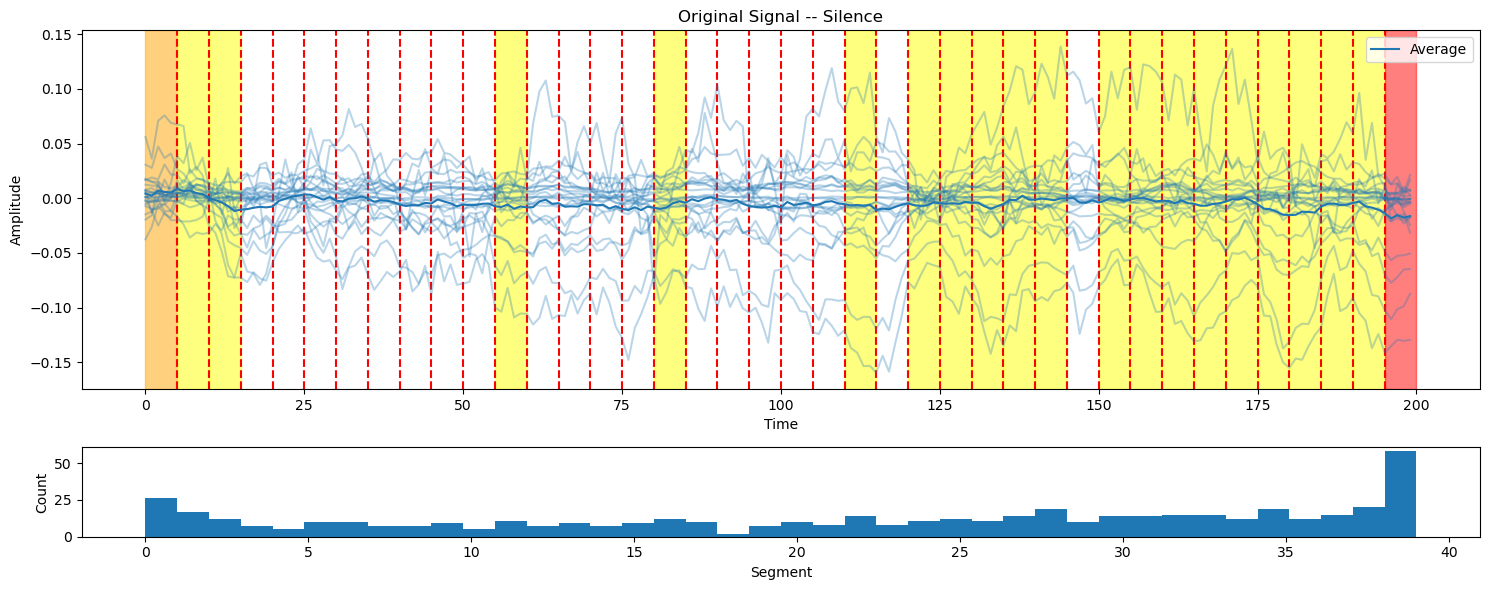

In [30]:
ave_channel_signal = total_signal_silence.mean(axis=0).reshape((23,200))
ave_total_signal = total_signal_silence.mean(axis=0).mean(axis=0)
n_samples = ave_total_signal.shape[-1]

counts, bins = np.histogram(important_segment_indices_silence,bins=num_slices)
def get_color(count, total_n):
    if count <= int(total_n*0.1):
        return "grey" # 10%
    elif count <= int(total_n*0.25):
        return "yellow" # 25%
    elif count <= int(total_n*0.5):
        return "orange" # 50%
    else:
        return "red" # >50%
seg_colors = [get_color(c, n_instances) for c in counts]

fig,axes = plt.subplots(2,1,figsize=(15, 6),height_ratios=(4,1))

for i in range(1, num_slices):
    axes[0].axvline(x=i * (n_samples // num_slices), color='r', linestyle='--')

for i in range(23):
    axes[0].plot(ave_channel_signal[i], alpha=0.3, color="tab:blue")
axes[0].plot(ave_total_signal, color="tab:blue", label="Average")
axes[0].legend()
for seg_idx,seg_color in zip(range(num_slices),seg_colors):
    if seg_color == "grey":
        continue
    start_idx = seg_idx * (n_samples // num_slices)
    end_idx = start_idx + (n_samples // num_slices)
    axes[0].axvspan(start_idx, end_idx, color=seg_color, alpha=0.5)  # Highlight influential segments

axes[0].set_title('Original Signal -- Silence')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Amplitude')

axes[1].hist(important_segment_indices_silence,bins=num_slices)
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Explore individual sequences

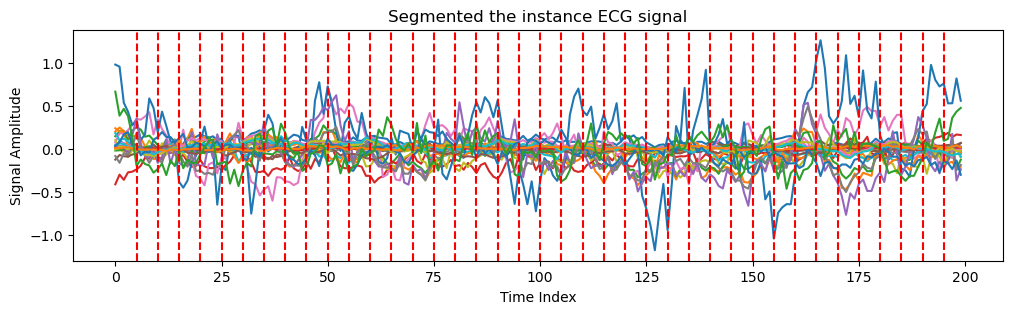

In [31]:
seq = np.array(total_signal_speech[0])

# Segmentation using the fixed number of slices
num_slices = 40 
slice_width = lime_explanation.segment_ecg_signal(seq, num_slices)

# plot the segmented ECG signal
lime_visualization.plot_segmented_ecg(seq, slice_width)

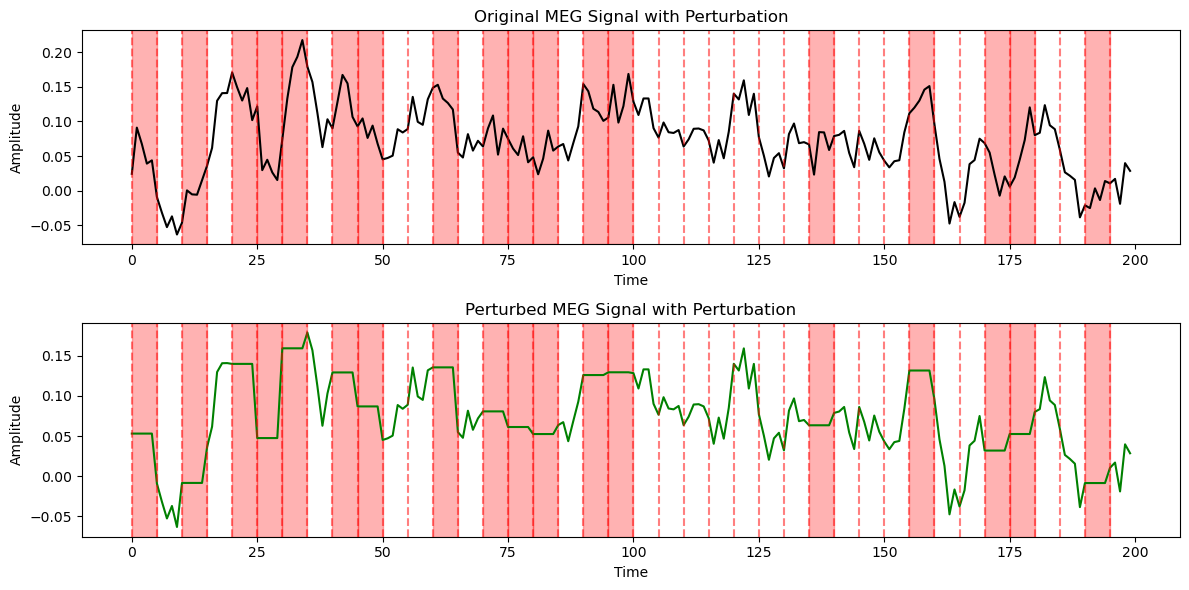

In [32]:
# Perturbation
random_perturbations = lime_explanation.generate_random_perturbations(num_perturbations, num_slices)

# Apply a random perturbation to the ECG signal
perturbed_ecg_example = lime_explanation.apply_perturbation_to_ecg(seq, random_perturbations[-1], num_slices, perturb_function)

# plot the original and perturbed ECG signals with highlighted slices and deactivated segments
lime_visualization.plot_perturbed_ecg(seq[0], perturbed_ecg_example[0], random_perturbations[-1], num_slices, title='MEG Signal with Perturbation')

In [38]:
random_perturbations

array([[0, 0, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 0, 0, 1],
       [0, 1, 0, ..., 0, 0, 1],
       ...,
       [1, 1, 0, ..., 1, 0, 1],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 1, 0, 1]], shape=(150, 40))

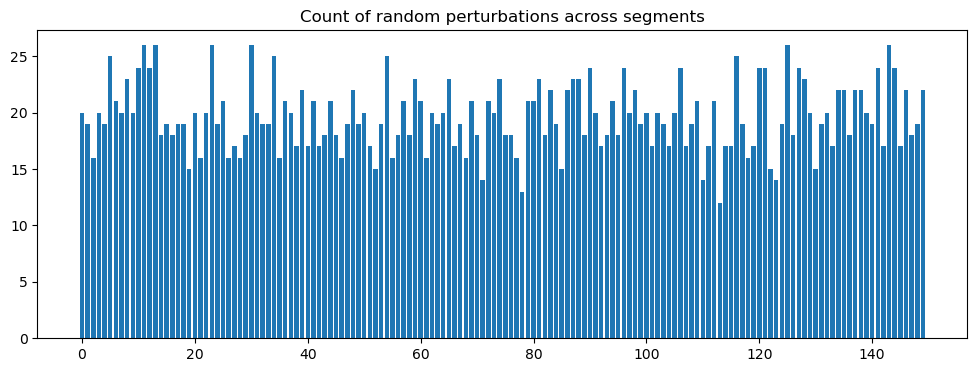

In [46]:
plt.figure(figsize=(12,4))
plt.bar(np.arange(150), random_perturbations.sum(axis=1))
plt.title("Count of random perturbations across segments")
plt.show()


In [33]:
## Predict the class probabilities using the trained ECG classifier
perturbation_predictions = lime_explanation.predict_perturbations(model, seq, random_perturbations, num_slices, lime_explanation.perturb_mean)
# Calculate cosine distances between each perturbation and the original ECG signal representation
cosine_distances = lime_explanation.calculate_cosine_distances(random_perturbations, num_slices)
#Applying a Kernel Function to Compute Weights
kernel_width = 0.25  # This can be adjusted based on your specific needs
weights = lime_explanation.calculate_weights_from_distances(cosine_distances, kernel_width)
# Constructing the Explainable Model for ECG Signals
segment_importance_coefficients = lime_explanation.fit_explainable_model(perturbation_predictions, random_perturbations, weights, target_class=1)
# identify most influential segments
top_influential_segments = lime_explanation.identify_top_influential_segments(segment_importance_coefficients, number_of_top_features)

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


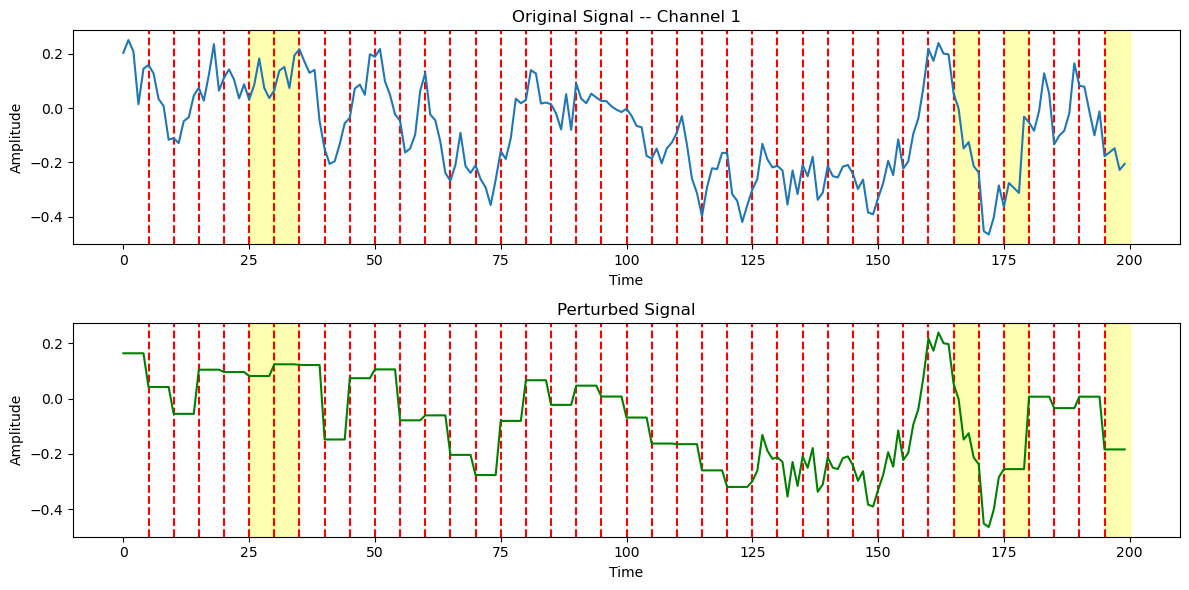

In [34]:
# single channel
lime_visualization.visualize_lime_explanation(seq, top_influential_segments, num_slices, perturb_function=lime_explanation.perturb_mean, channel=1)

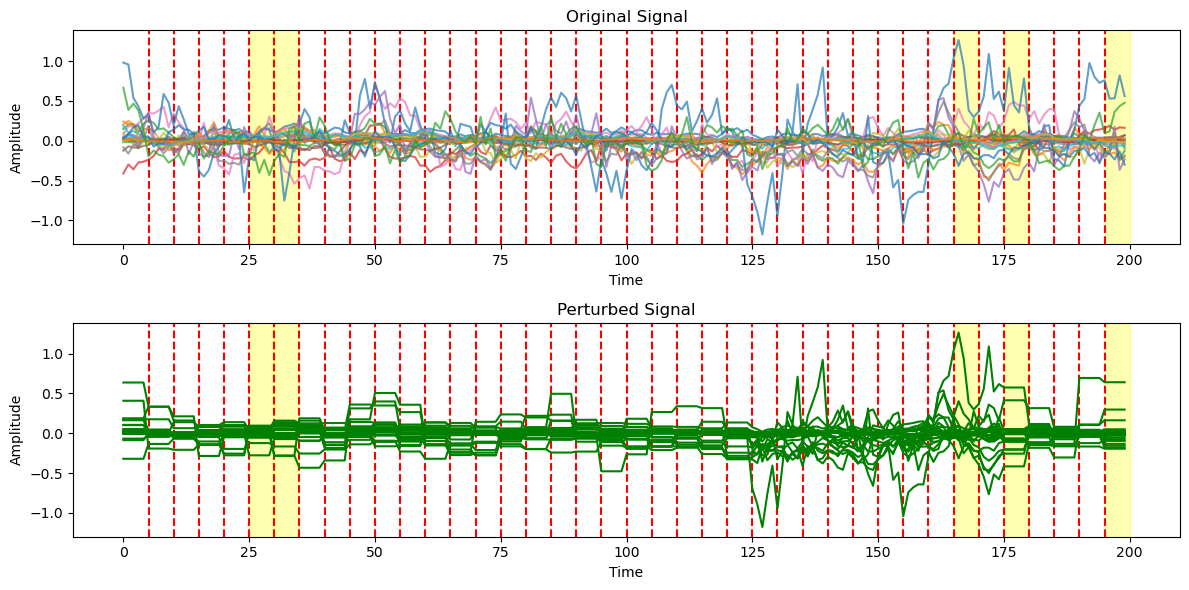

In [35]:
# all channels
lime_visualization.visualize_lime_explanation_all_channels(seq, top_influential_segments, num_slices, perturb_function=lime_explanation.perturb_mean)

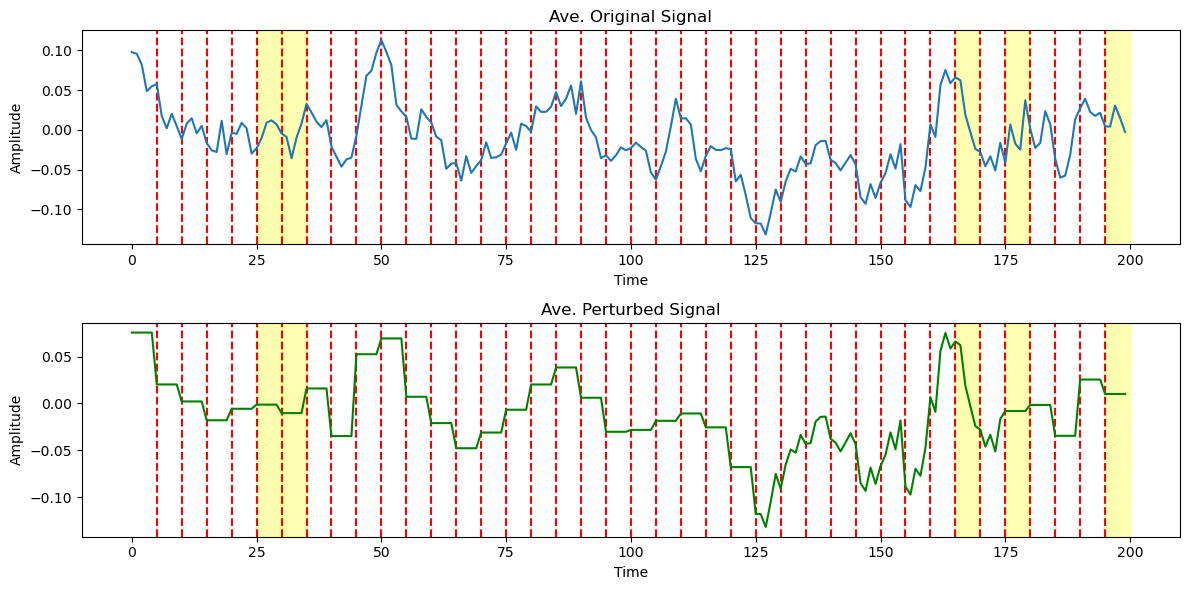

In [36]:
# average all channels
lime_visualization.visualize_ave_lime_explanation(seq, top_influential_segments, num_slices, perturb_function=lime_explanation.perturb_mean)